In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.tracebacklimit = 0
from datetime import datetime as dt

In [17]:
def read_data():
    # Read the data (tab-separated, with French column names)
    file_path = fr'C:/Users/jeand/Downloads/EUR{cur}SPOT_{year}-{month}-{day}{span}.txt'

    try:
        data = pd.read_csv(file_path, sep='\t', parse_dates=['date'], dayfirst=True).dropna(axis=1, how='all')  # 'dayfirst=True' because dates are in dd/mm/yyyy format
    except:
        file_path = fr'C:/Users/jeand/Downloads/EUR{cur}SPOT_{year}-{month}-{day}.txt'
        data = pd.read_csv(file_path, sep='\t', parse_dates=['date'], dayfirst=True).dropna(axis=1, how='all')  
    
    data.drop(columns=['vol','devise'], inplace=True)  # Drop 'vol' column if it exists, as it's not needed for plotting
    # Set 'date' as index and sort (critical for time series)
    d2 = data['date'].apply(lambda x: x.strftime('%d/%m/%Y %H:%M:%S'))  # Format dates for plotting
    data = data.set_index('date').sort_index()  # Sort to ensure chronological order
    dates = data.index
    #print(data)
    # Extract closing prices ('clot' column)
    close_prices = data['clot']
    #dates = data.index
    return data, dates, close_prices, d2

# This function plots the absolute price and % variation from the first closing price
def plot_data(data):
    # Calculate % variation from first closing price
    first_close = close_prices.iloc[0]
    data['pct_change'] = (close_prices / first_close - 1) * 100

    # Create figure and primary axis (left, absolute price)
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(dates, close_prices, color='blue', label=f'Closing Price ({cur})')
    ax1.set_xlabel('Time')
    ax1.set_ylabel(f'Absolute Price ({cur})', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True)

    # Add secondary axis (right, % variation)
    ax2 = ax1.twinx()
    ax2.set_ylabel('% Variation (from First Close)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # --- Key Fix: Sync axes so 0% aligns with first_close ---
    def sync_axes(ax1, ax2, first_close):
        """Sync left (absolute) and right (%) axes."""
        y1_min, y1_max = ax1.get_ylim()
        # Convert left axis limits to % variation
        pct_min = (y1_min / first_close - 1) * 100
        pct_max = (y1_max / first_close - 1) * 100
        ax2.set_ylim(pct_min, pct_max)

    sync_axes(ax1, ax2, first_close)  # Apply synchronization

    # Optional: Mark reference price and 0% line
    ax1.axhline(y=first_close, color='gray', linestyle='--', linewidth=1, label=f'Reference: {first_close} {cur}')
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)  # 0% line (redundant but clear)

    # Title and legend
    plt.title(f'EUR/{cur} Spot Rate: Absolute Price with % Variation ({day}/{month}/{year} - Span: {span_str})')
    ax1.legend(loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def format_date_heure(x): # date/heure pour axe x
    global memo
    jour = x[:2]
    heure = x[11:16]
    if jour == memo:
        jour = ''
    memo = x[:2]
    return jour+'\n'+heure

def plot_absprices():
    # Plot absolute price
    plt.figure(figsize=(12, 8))
    plt.plot(dates, close_prices, label=f'EUR/{cur} Closing Price', color='red', marker='o', markersize=2, linestyle='-', linewidth=1)
    plt.title(f'EUR/{cur} Spot Rate - Closing Prices ({day}/{month}/{year}) - Span : {span_str}')
    plt.xlabel('Time')
    plt.ylabel(f'Price ({cur})')
    #plt.xticks(ticks=range(len(d)), labels=d)
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to prevent label cutoff
    #plt.show()

def max_min():
    max_clot = close_prices.max()
    max_clot_time = close_prices.idxmax()
    print(f"Maximum closing price (clot): {max_clot} {cur} at {max_clot_time}")
    min_clot = close_prices.min()
    min_clot_time = close_prices.idxmin()
    print(f"Minimum closing price (clot): {min_clot} {cur} at {min_clot_time}")

# Plot span data in the currency cur


In [18]:

year = str(dt.now().year).zfill(2)
day = str(int(dt.now().day)).zfill(2)  # Today file
month = str(dt.now().month).zfill(2)
cur = 'VND' # Change to 'USD', 'VND' or other currency as needed

span_dict = {'': 'No Span', '1M': '1 Month', '3M': '3 Months', '6M': '6 Months', '1Y': '1 Year', '5Y': '5 Years', '10Y': '10 Years', '5days': '5 days'} 
span = '10Y'  # Options: '', '1M', '3M', '6M', '1Y', '5Y', '10Y'
span_str = span_dict.get(span, 'No Span')
memo = '' # for date/heure x axis formatting

# Read the data (tab-separated, with French column names)
try: # 5_days data back from today
    file_path = fr'C:/Users/jeand/Downloads/EUR{cur}SPOT_{year}-{month}-{day}_{span}.txt'
    data = pd.read_csv(file_path, sep='\t', parse_dates=['date'], dayfirst=True).dropna(axis=1, how='all')  # 'dayfirst=True' because dates are in dd/mm/yyyy format
    print(f"File found for {day}/{month}/{year}: {file_path}")
except FileNotFoundError as e:      
        print(f"File not found for {day}/{month}/{year}: {file_path}")
        print("Download today data from https://www.boursorama.com/bourse/devises/taux-de-change-euro-dong-EUR-VND/ and save it as EURVNDSPOT_YYYY-MM-DD_5days.txt in Downloads folder") 
        # use yesterday's 5_days datafile if today is not available
        day = str(int(dt.now().day)-1).zfill(2) # Yesterday file
        file_path = fr'C:/Users/jeand/Downloads/EURVNDSPOT_{year}-{month}-{day}_5days.txt'
        data = pd.read_csv(file_path, sep='\t', parse_dates=['date'], dayfirst=True).dropna(axis=1, how='all')  # 'dayfirst=True' because dates are in dd/mm/yyyy format

        #raise ValueError("Download today data from https://www.investing.com/currencies/eur-vnd-historical-data and save it as EURVNDSPOT_YYYY-MM-DD.txt in Downloads folder") 
        #continue 
data.drop(columns=['vol','devise'], inplace=True)  # Drop 'vol' column if it exists, as it's not needed for plotting
# Set 'date' as index and sort (critical for time series)
d2 = data['date'].apply(lambda x: x.strftime('%d/%m/%Y %H:%M:%S'))  # Format dates for plotting
data = data.set_index('date').sort_index()  # Sort to ensure chronological order

# Extract closing prices ('clot' column)
close_prices = data['clot']
dates = data.index
data

File found for 13/10/2025: C:/Users/jeand/Downloads/EURVNDSPOT_2025-10-13_10Y.txt


,ouv,haut,bas,clot
date,,,,
2015-10-13,25387.460,25569.610,25361.078,25503.704
2015-10-14,25508.186,25732.976,25501.797,25711.700
2015-10-15,25709.461,25736.335,25388.315,25418.460
2015-10-16,25421.805,25428.731,25254.271,25286.720
2015-10-19,25286.720,25400.376,25223.798,25276.117
...,...,...,...,...
2025-10-06,30944.171,30979.001,30721.278,30875.981
2025-10-07,30875.981,30886.833,30710.542,30735.603
2025-10-08,30742.771,30749.942,30580.047,30651.163


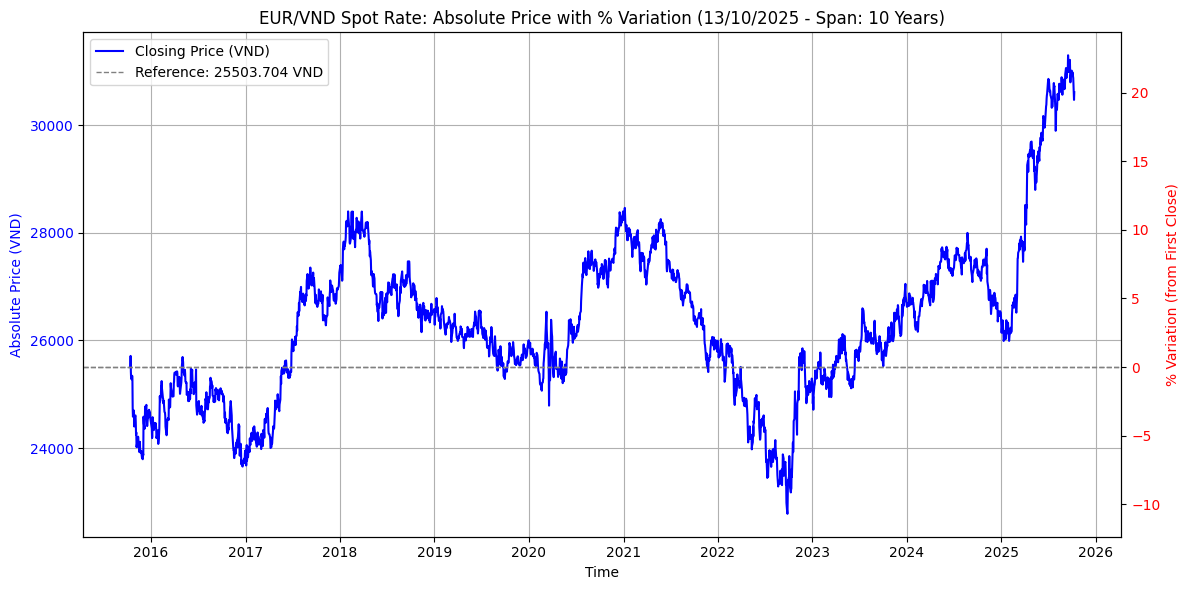

In [19]:
plot_data(data)